In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def sim_var_model(c, A_1, A_2, Sigma, T, seed=None):
    np.random.seed(seed)
    assert(T >= 1)

    K = len(c)
    Y = np.zeros((T, K))
    
    epsilon = np.random.multivariate_normal(np.zeros(K), Sigma, size = T, check_valid='warn', tol=1e-8)

    mu = np.linalg.inv(np.eye(K) - A_1 - A_2) @ c
    Y[0, ] = np.random.multivariate_normal(mu, Sigma)
    Y[1, ] = np.random.multivariate_normal(mu, Sigma)

    for t in range(2, T):
        Y[t, ] = c + A_1 @ Y[t-1, ] + A_2 @ Y[t-2, ] + epsilon[t]
    return(Y)

Wrote the function for the VAR(2) process.

In [2]:
T = 200
c = np.array([2.5, 1.5])
A_1 = np.array([[0.45, -0.35], 
                  [-0.15, 0.3]])
A_2 = np.array([[0.05, -0.05],
                  [-0.05, 0.03]])
Sigma = np.array([[1, 0.1],
                  [0.1, 0.5]])

companion = np.block([
    [A_1, A_2],
    [np.eye(2), np.zeros([2, 2])]
])
eigenvalues = np.linalg.eigvals(companion)
print(np.abs(eigenvalues))

[0.74273007 0.10745252 0.10745252 0.11661   ]


Confirming that the VAR(2) selected is stable by checking the eigenvalues.

<Axes: xlabel='t', ylabel='value'>

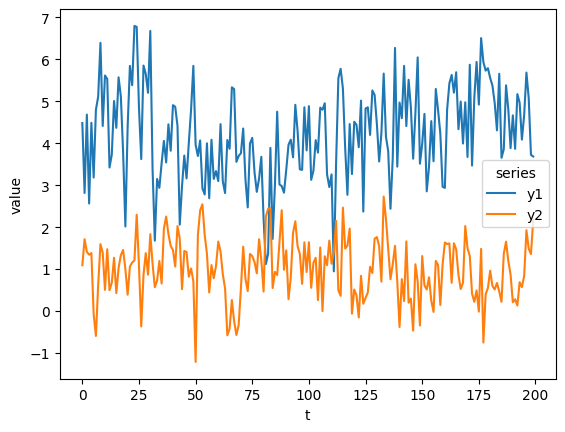

In [3]:
Y = sim_var_model(c, A_1, A_2, Sigma, T, seed=None)
np.savetxt("Y_sim.csv", Y, delimiter=",")

df = pd.DataFrame(Y, columns=["y1", "y2"])
df["t"] = range(T)
df_long = df.melt(id_vars="t", var_name="series", value_name="value")

sns.lineplot(data=df_long, x="t", y="value", hue="series")

Plotting synthetic data, and saving simulated data.

In [6]:
from cmdstanpy import CmdStanModel, set_cmdstan_path
set_cmdstan_path("/deac/sta/classes/sta720/software/cmdstan/2.37.0")

stan_data = {
    "T": T,
    "K": len(c),
    "Y": Y
}

var_mod = CmdStanModel(stan_file="var-2.stan")
var_mod_post = var_mod.sample(data = stan_data)
print(var_mod_post.diagnose())
var_mod_params = var_mod_post.stan_variables()

14:39:53 - cmdstanpy - INFO - compiling stan file /deac/sta/cademartoriGrp/hatan25/wfu-thesis/notebooks/var-2.stan to exe file /deac/sta/cademartoriGrp/hatan25/wfu-thesis/notebooks/var-2
14:40:15 - cmdstanpy - INFO - compiled model executable: /deac/sta/cademartoriGrp/hatan25/wfu-thesis/notebooks/var-2
14:40:15 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:03<00:12, 131.99it/s, (Warmup)]

chain 1:  40%|████      | 800/2000 [00:05<00:06, 177.16it/s, (Warmup)]


chain 1:  60%|██████    | 1200/2000 [00:07<00:04, 175.69it/s, (Sampling)]

chain 1:  80%|████████  | 1600/2000 [00:09<00:02, 186.14it/s, (Sampling)]

chain 1:  95%|█████████▌| 1900/2000 [00:11<00:00, 180.75it/s, (Sampling)]

chain 1: 100%|██████████| 2000/2000 [00:12<00:00, 155.77it/s, (Sampling)]















































chain 2: 100%|██████████| 2000/2000 [00:26<00:00, 75.68it/s, (Sampling completed)] 

cha


14:40:42 - cmdstanpy - INFO - CmdStan done processing.
14:40:42 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var-2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var-2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var-2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var-2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var-2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var-2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf: Correlation matrix is not positive definite. (in 'var-2.stan', line 22, column 4 to column 22)
	Exception: lkj_corr_lpdf


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [7]:
print("True c:", c)
print("Estimated c:", var_mod_params["c"].mean(axis=0))

print("True A_1:", A_1)
print("Estimated A_1:", var_mod_params["A_1"].mean(axis=0))

print("True A_2:", A_2)
print("Estimated A_2:", var_mod_params["A_2"].mean(axis=0))

print(var_mod_post.summary())

True c: [2.5 1.5]
Estimated c: [3.01363977 1.0817365 ]
True A_1: [[ 0.45 -0.35]
 [-0.15  0.3 ]]
Estimated A_1: [[ 0.32420469 -0.26599258]
 [-0.12298763  0.34875685]]
True A_2: [[ 0.05 -0.05]
 [-0.05  0.03]]
Estimated A_2: [[ 0.078951   -0.23106851]
 [ 0.02609648 -0.0245297 ]]
                Mean      MCSE    StdDev       MAD          5%         50%  \
lp__     -116.689000  0.062136  2.559850  2.337000 -121.429000 -116.322000   
c[1]        3.013640  0.007199  0.375504  0.371734    2.388770    3.024030   
c[2]        1.081740  0.005140  0.253736  0.258658    0.667248    1.080930   
A_1[1,1]    0.324205  0.001341  0.073215  0.073035    0.203940    0.323435   
A_1[1,2]   -0.265993  0.001788  0.110283  0.109626   -0.447321   -0.266528   
A_1[2,1]   -0.122988  0.001047  0.050995  0.052008   -0.206478   -0.123556   
A_1[2,2]    0.348757  0.001295  0.072690  0.073468    0.230410    0.347991   
A_2[1,1]    0.078951  0.001280  0.070629  0.071036   -0.036505    0.078805   
A_2[1,2]   -0.231069 

Everything looks like it ran correctly, posterior intervals capture our true values.

In [9]:
stan_data_hier = {
    "T": T,
    "K": len(c),
    "P": 2,
    "Y": Y
}

var_mod_hier = CmdStanModel(stan_file="var-2-hierarchical.stan")
var_mod_hier_post = var_mod_hier.sample(data = stan_data_hier)
print(var_mod_hier_post.diagnose())
var_mod_hier_params = var_mod_hier_post.stan_variables()

14:41:10 - cmdstanpy - INFO - compiling stan file /deac/sta/cademartoriGrp/hatan25/wfu-thesis/notebooks/var-2-hierarchical.stan to exe file /deac/sta/cademartoriGrp/hatan25/wfu-thesis/notebooks/var-2-hierarchical
14:41:32 - cmdstanpy - INFO - compiled model executable: /deac/sta/cademartoriGrp/hatan25/wfu-thesis/notebooks/var-2-hierarchical
14:41:32 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]




chain 1:   5%|▌         | 100/2000 [00:07<02:18, 13.73it/s, (Warmup)]



chain 1:  10%|█         | 200/2000 [00:10<01:32, 19.55it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:13<01:09, 24.63it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:16<00:54, 29.37it/s, (Warmup)]




chain 1:  25%|██▌       | 500/2000 [00:18<00:45, 32.72it/s, (Warmup)]




chain 1:  30%|███       | 600/2000 [00:19<00:35, 39.81it/s, (Warmup)]






chain 1:  35%|███▌      | 700/2000 [00:21<00:27, 46.45it/s, (Warmup)]


chain 1:  40%|████      |


14:42:07 - cmdstanpy - INFO - CmdStan done processing.
14:42:07 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'var-2-hierarchical.stan', line 27, column 4 to column 26)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'var-2-hierarchical.stan', line 27, column 4 to column 26)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'var-2-hierarchical.stan', line 27, column 4 to column 26)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'var-2-hierarchical.stan', line 27, column 4 to column 26)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'var-2-hierarchical.stan', line 27, column 4 to column 26)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'var-2-hierarchical.stan', line 27, column 4 to column 26)
	Exception: lkj_corr_lpdf: Correlation 


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [10]:
print("True c:", c)
print("Estimated c:", var_mod_hier_params["c"].mean(axis=0))

print("True A_1:", A_1)
print("True A_2:", A_2)
print("Estimated A:", var_mod_hier_params["A"].mean(axis=0))

print(var_mod_hier_post.summary())

True c: [2.5 1.5]
Estimated c: [2.66524118 1.03220265]
True A_1: [[ 0.45 -0.35]
 [-0.15  0.3 ]]
True A_2: [[ 0.05 -0.05]
 [-0.05  0.03]]
Estimated A: [[[ 0.37450882 -0.20720055]
  [-0.11471591  0.3672999 ]]

 [[ 0.0628865  -0.08413106]
  [ 0.02320168 -0.01472326]]]
                Mean      MCSE    StdDev       MAD          5%         50%  \
lp__     -120.137000  0.065937  2.762830  2.691560 -125.139000 -119.819000   
c[1]        2.665240  0.007529  0.363797  0.366486    2.054300    2.670880   
c[2]        1.032200  0.005083  0.256274  0.254728    0.614481    1.030760   
A[1,1,1]    0.374509  0.001325  0.070567  0.068788    0.260555    0.373245   
A[1,1,2]   -0.207201  0.001864  0.095261  0.097310   -0.366753   -0.207948   
A[1,2,1]   -0.114716  0.000914  0.048621  0.049261   -0.194287   -0.114264   
A[1,2,2]    0.367300  0.001235  0.072399  0.074721    0.251491    0.367173   
A[2,1,1]    0.062886  0.001131  0.064274  0.066427   -0.041340    0.063507   
A[2,1,2]   -0.084131  0.001407  